In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_table("total_degs_promoter_histonesignal.txt",header=None)
df.columns = ["chr", "start", "end", "wt-k27ac_1", "wt-k27ac_2",'wt-4me3_1','wt-4me3_2','wt-27me3_1','wt-27me3_2', "wt-input_1", "wt-input_2", "pi-k27ac_1", "pi-k27ac_2",'pi-4me3_1','pi-4me3_2','pi-27me3_1','pi-27me3_2',"pi-input_1", "pi-input_2","DEGs"]
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,wt-input_2,pi-k27ac_1,pi-k27ac_2,pi-4me3_1,pi-4me3_2,pi-27me3_1,pi-27me3_2,pi-input_1,pi-input_2,DEGs
0,chr6,54460804,54464804,1128.0,1547.0,1975.0,1922.0,170.0,231.0,147.0,159.0,1492.0,2335.0,733.0,3674.0,74.0,131.0,104.0,69.0,down
1,chr1,228852095,228856095,247.0,406.0,971.0,782.0,214.0,218.0,49.0,56.0,437.0,668.0,196.0,1063.0,86.0,216.0,26.0,32.0,down
2,chr5,79280050,79284050,73.0,42.0,32.0,29.0,16.0,31.0,14.0,15.0,19.0,39.0,10.0,55.0,6.0,10.0,17.0,10.0,down
3,chr3,46021905,46025905,65.0,115.0,48.0,51.0,191.0,249.0,34.0,27.0,94.0,151.0,8.0,74.0,118.0,204.0,25.0,37.0,down
4,chr1,130562062,130566062,676.0,1160.0,1516.0,1283.0,80.0,85.0,113.0,125.0,1136.0,1796.0,488.0,2297.0,30.0,53.0,50.0,89.0,down


In [3]:
#calibrate depth
df["wt-k27ac_1nor"] = df["wt-k27ac_1"]/47
df["wt-k27ac_2nor"] = df["wt-k27ac_2"]/53
df["wt-4me3_1nor"] = df["wt-4me3_1"]/37
df["wt-4me3_2nor"] = df["wt-4me3_2"]/34
df["wt-k27me3_1nor"] = df["wt-27me3_1"]/63
df["wt-k27me3_2nor"] = df["wt-27me3_2"]/73
df["wt-igg_1nor"] = df["wt-input_1"]/10
df["wt-igg_2nor"] = df["wt-input_2"]/10
df["pi-k27ac_1nor"] = df["pi-k27ac_1"]/38
df["pi-k27ac_2nor"] = df["pi-k27ac_2"]/59
df["pi-4me3_1nor"] = df["pi-4me3_1"]/13
df["pi-4me3_2nor"] = df["pi-4me3_2"]/58
df["pi-k27me3_1nor"] = df["pi-27me3_1"]/26
df["pi-k27me3_2nor"] = df["pi-27me3_2"]/46
df["pi-igg_1nor"] = df["pi-input_1"]/8
df["pi-igg_2nor"] = df["pi-input_2"]/9
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,wt-igg_1nor,wt-igg_2nor,pi-k27ac_1nor,pi-k27ac_2nor,pi-4me3_1nor,pi-4me3_2nor,pi-k27me3_1nor,pi-k27me3_2nor,pi-igg_1nor,pi-igg_2nor
0,chr6,54460804,54464804,1128.0,1547.0,1975.0,1922.0,170.0,231.0,147.0,...,14.7,15.9,39.263158,39.576271,56.384615,63.344828,2.846154,2.847826,13.000,7.666667
1,chr1,228852095,228856095,247.0,406.0,971.0,782.0,214.0,218.0,49.0,...,4.9,5.6,11.500000,11.322034,15.076923,18.327586,3.307692,4.695652,3.250,3.555556
2,chr5,79280050,79284050,73.0,42.0,32.0,29.0,16.0,31.0,14.0,...,1.4,1.5,0.500000,0.661017,0.769231,0.948276,0.230769,0.217391,2.125,1.111111
3,chr3,46021905,46025905,65.0,115.0,48.0,51.0,191.0,249.0,34.0,...,3.4,2.7,2.473684,2.559322,0.615385,1.275862,4.538462,4.434783,3.125,4.111111
4,chr1,130562062,130566062,676.0,1160.0,1516.0,1283.0,80.0,85.0,113.0,...,11.3,12.5,29.894737,30.440678,37.538462,39.603448,1.153846,1.152174,6.250,9.888889


In [4]:
df['wt-k27ac_mean'] = df[['wt-k27ac_1nor', 'wt-k27ac_2nor']].mean(axis=1)
df['wt-4me3_mean'] = df[['wt-4me3_1nor', 'wt-4me3_2nor']].mean(axis=1)
df['wt-k27me3_mean'] = df[['wt-k27me3_1nor', 'wt-k27me3_2nor']].mean(axis=1)
df['wt-igg_mean'] = df[['wt-igg_1nor', 'wt-igg_2nor']].mean(axis=1)

In [5]:
df['pi-k27ac_mean'] = df[['pi-k27ac_1nor', 'pi-k27ac_2nor']].mean(axis=1)
df['pi-4me3_mean'] = df[['pi-4me3_1nor', 'pi-4me3_2nor']].mean(axis=1)
df['pi-k27me3_mean'] = df[['pi-k27me3_1nor', 'pi-k27me3_2nor']].mean(axis=1)
df['pi-igg_mean'] = df[['pi-igg_1nor', 'pi-igg_2nor']].mean(axis=1)

In [6]:
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,pi-igg_1nor,pi-igg_2nor,wt-k27ac_mean,wt-4me3_mean,wt-k27me3_mean,wt-igg_mean,pi-k27ac_mean,pi-4me3_mean,pi-k27me3_mean,pi-igg_mean
0,chr6,54460804,54464804,1128.0,1547.0,1975.0,1922.0,170.0,231.0,147.0,...,13.000,7.666667,26.594340,54.953895,2.931398,15.30,39.419715,59.864721,2.846990,10.333333
1,chr1,228852095,228856095,247.0,406.0,971.0,782.0,214.0,218.0,49.0,...,3.250,3.555556,6.457848,24.621622,3.191563,5.25,11.411017,16.702255,4.001672,3.402778
2,chr5,79280050,79284050,73.0,42.0,32.0,29.0,16.0,31.0,14.0,...,2.125,1.111111,1.172822,0.858903,0.339313,1.45,0.580508,0.858753,0.224080,1.618056
3,chr3,46021905,46025905,65.0,115.0,48.0,51.0,191.0,249.0,34.0,...,3.125,4.111111,1.776395,1.398649,3.221352,3.05,2.516503,0.945623,4.486622,3.618056
4,chr1,130562062,130566062,676.0,1160.0,1516.0,1283.0,80.0,85.0,113.0,...,6.250,9.888889,18.134886,39.354134,1.217112,11.90,30.167707,38.570955,1.153010,8.069444


In [7]:
df["wt-k27ac_change"] = np.log2((df["wt-k27ac_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["wt-4me3_change"] = np.log2((df["wt-4me3_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["wt-k27me3_change"] = np.log2((df["wt-k27me3_mean"] + 1e-3)/(df["wt-igg_mean"] + 1e-3))
df["pi-k27ac_change"] = np.log2((df["pi-k27ac_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df["pi-4me3_change"] = np.log2((df["pi-4me3_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df["pi-k27me3_change"] = np.log2((df["pi-k27me3_mean"] + 1e-3)/(df["pi-igg_mean"] + 1e-3))
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,pi-k27ac_mean,pi-4me3_mean,pi-k27me3_mean,pi-igg_mean,wt-k27ac_change,wt-4me3_change,wt-k27me3_change,pi-k27ac_change,pi-4me3_change,pi-k27me3_change
0,chr6,54460804,54464804,1128.0,1547.0,1975.0,1922.0,170.0,231.0,147.0,...,39.419715,59.864721,2.846990,10.333333,0.797548,1.844622,-2.383473,1.931509,2.534285,-1.859429
1,chr1,228852095,228856095,247.0,406.0,971.0,782.0,214.0,218.0,49.0,...,11.411017,16.702255,4.001672,3.402778,0.298685,2.229320,-0.717877,1.745345,2.294920,0.233827
2,chr5,79280050,79284050,73.0,42.0,32.0,29.0,16.0,31.0,14.0,...,0.580508,0.858753,0.224080,1.618056,-0.305834,-0.754802,-2.092114,-1.477280,-0.913158,-2.846641
3,chr3,46021905,46025905,65.0,115.0,48.0,51.0,191.0,249.0,34.0,...,2.516503,0.945623,4.486622,3.618056,-0.779518,-1.124217,0.078832,-0.523620,-1.934751,0.310338
4,chr1,130562062,130566062,676.0,1160.0,1516.0,1283.0,80.0,85.0,113.0,...,30.167707,38.570955,1.153010,8.069444,0.607764,1.725469,-3.288364,1.902333,2.256832,-2.805992


In [8]:
df.loc[df['wt-k27ac_change'] < 0, 'wt-k27ac_change'] = 0
df.loc[df['wt-4me3_change'] < 0, 'wt-4me3_change'] = 0
df.loc[df['wt-k27me3_change'] < 0, 'wt-k27me3_change'] = 0
df.loc[df['pi-k27ac_change'] < 0, 'pi-k27ac_change'] = 0
df.loc[df['pi-4me3_change'] < 0, 'pi-4me3_change'] = 0
df.loc[df['pi-k27me3_change'] < 0, 'pi-k27me3_change'] = 0
df.head()

,chr,start,end,wt-k27ac_1,wt-k27ac_2,wt-4me3_1,wt-4me3_2,wt-27me3_1,wt-27me3_2,wt-input_1,...,pi-k27ac_mean,pi-4me3_mean,pi-k27me3_mean,pi-igg_mean,wt-k27ac_change,wt-4me3_change,wt-k27me3_change,pi-k27ac_change,pi-4me3_change,pi-k27me3_change
0,chr6,54460804,54464804,1128.0,1547.0,1975.0,1922.0,170.0,231.0,147.0,...,39.419715,59.864721,2.846990,10.333333,0.797548,1.844622,0.000000,1.931509,2.534285,0.000000
1,chr1,228852095,228856095,247.0,406.0,971.0,782.0,214.0,218.0,49.0,...,11.411017,16.702255,4.001672,3.402778,0.298685,2.229320,0.000000,1.745345,2.294920,0.233827
2,chr5,79280050,79284050,73.0,42.0,32.0,29.0,16.0,31.0,14.0,...,0.580508,0.858753,0.224080,1.618056,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,chr3,46021905,46025905,65.0,115.0,48.0,51.0,191.0,249.0,34.0,...,2.516503,0.945623,4.486622,3.618056,0.000000,0.000000,0.078832,0.000000,0.000000,0.310338
4,chr1,130562062,130566062,676.0,1160.0,1516.0,1283.0,80.0,85.0,113.0,...,30.167707,38.570955,1.153010,8.069444,0.607764,1.725469,0.000000,1.902333,2.256832,0.000000


In [18]:
h3k27ac = df[["chr","start","end","wt-k27ac_change","pi-k27ac_change","DEGs"]] 
h3k27ac.head()
#h3k27ac.to_csv("h3k27ac_change.txt", sep="\t", index=False)

,chr,start,end,wt-k27ac_change,pi-k27ac_change,DEGs
0,chr6,54460804,54464804,0.797548,1.931509,down
1,chr1,228852095,228856095,0.298685,1.745345,down
2,chr5,79280050,79284050,0.000000,0.000000,down
3,chr3,46021905,46025905,0.000000,0.000000,down
4,chr1,130562062,130566062,0.607764,1.902333,down


In [36]:
h3k27me3 = df[["chr","start","end","wt-k27me3_change","pi-k27me3_change","DEGs"]] 
h3k27me3.head()
h3k27me3.to_csv("h3k27me3_change.txt", sep="\t", index=False)

In [11]:
h3k4me3 = df[["chr","start","end","wt-4me3_change","pi-4me3_change","DEGs"]] 
h3k4me3.head()
h3k4me3.to_csv("h3k4me3_change.txt", sep="\t", index=False)

In [21]:
h3k27ac = h3k27ac[~((h3k27ac['wt-k27ac_change'] <= 0) & (h3k27ac['pi-k27ac_change'] <= 0))]
h3k27ac['change'] = h3k27ac['pi-k27ac_change'] - h3k27ac['wt-k27ac_change']
h3k27ac.head()

,chr,start,end,wt-k27ac_change,pi-k27ac_change,DEGs,change
0,chr6,54460804,54464804,0.797548,1.931509,down,1.133961
1,chr1,228852095,228856095,0.298685,1.745345,down,1.446660
4,chr1,130562062,130566062,0.607764,1.902333,down,1.294568
5,chr12,34898096,34902096,0.658880,0.359745,down,-0.299135
6,chr15,106774125,106778125,0.476676,2.000070,down,1.523395


In [32]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu, normaltest

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

down vs. none: Mann-Whitney-Wilcoxon test two-sided, P_val:7.616e-14 U_stat=2.205e+06
none vs. up: Mann-Whitney-Wilcoxon test two-sided, P_val:1.640e-02 U_stat=4.578e+06


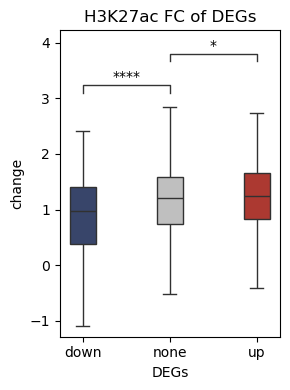

In [43]:
fig, ax = plt.subplots(figsize=(3,4))
ax = sns.boxplot(x='DEGs', y='change', hue="DEGs", data=h3k27ac, showfliers=False,width=0.3,palette=("#304172","#bfbfbf", "#c0271d"))
pairs = [('down','none'),('none','up')]
annotator = Annotator(ax, pairs, x='DEGs', y='change', hue="DEGs", data=h3k27ac, showfliers=False,width=0.3,palette=("#304172","#bfbfbf", "#c0271d"))
annotator.configure(test='Mann-Whitney', text_format='star',line_height=0.03, line_width=1)
annotator.apply_and_annotate()
plt.title("H3K27ac FC of DEGs")
plt.savefig("degs_27ac_fc.pdf")
plt.tight_layout()
plt.show()

In [38]:
h3k27me3 = h3k27me3[~((h3k27me3['wt-k27me3_change'] <= 0) & (h3k27me3['pi-k27me3_change'] <= 0))]
h3k27me3['change'] = h3k27me3['pi-k27me3_change'] - h3k27me3['wt-k27me3_change']
h3k27me3.head()

,chr,start,end,wt-k27me3_change,pi-k27me3_change,DEGs,change
1,chr1,228852095,228856095,0.000000,0.233827,down,0.233827
3,chr3,46021905,46025905,0.078832,0.310338,down,0.231506
16,chr6,70023873,70027873,0.615573,0.861431,down,0.245858
23,chr4,90367735,90371735,1.772769,2.512751,down,0.739981
25,chr13,27355074,27359074,1.350109,0.353288,down,-0.996821


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

none vs. up: Mann-Whitney-Wilcoxon test two-sided, P_val:5.505e-01 U_stat=1.368e+05
down vs. none: Mann-Whitney-Wilcoxon test two-sided, P_val:7.359e-01 U_stat=1.517e+05


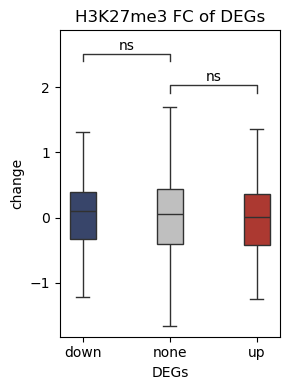

In [44]:
fig, ax = plt.subplots(figsize=(3,4))
ax = sns.boxplot(x='DEGs', y='change', hue="DEGs", data=h3k27me3, showfliers=False,width=0.3,palette=("#304172","#bfbfbf", "#c0271d"))
pairs = [('up','none'),('none','down')]
annotator = Annotator(ax, pairs, x='DEGs', y='change', hue="DEGs", data=h3k27me3, showfliers=False,width=0.3,palette=("#304172","#bfbfbf", "#c0271d"))
annotator.configure(test='Mann-Whitney', text_format='star',line_height=0.03, line_width=1)
annotator.apply_and_annotate()
plt.title("H3K27me3 FC of DEGs")
plt.savefig("degs_27me3_fc.pdf")
plt.tight_layout()
plt.show()

In [42]:
h3k4me3 = h3k4me3[~((h3k4me3['wt-4me3_change'] <= 0) & (h3k4me3['pi-4me3_change'] <= 0))]
h3k4me3['change'] = h3k4me3['pi-4me3_change'] - h3k4me3['wt-4me3_change']
h3k4me3.head()

,chr,start,end,wt-4me3_change,pi-4me3_change,DEGs,change
0,chr6,54460804,54464804,1.844622,2.534285,down,0.689663
1,chr1,228852095,228856095,2.229320,2.294920,down,0.065600
4,chr1,130562062,130566062,1.725469,2.256832,down,0.531363
6,chr15,106774125,106778125,2.500677,3.463217,down,0.962539
7,chr14,49915969,49919969,1.819551,1.545662,down,-0.273889


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

down vs. none: Mann-Whitney-Wilcoxon test two-sided, P_val:9.232e-05 U_stat=1.873e+06
none vs. up: Mann-Whitney-Wilcoxon test two-sided, P_val:4.459e-11 U_stat=3.430e+06


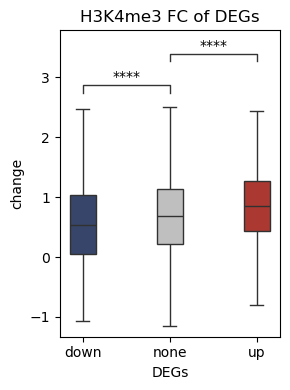

In [46]:
fig, ax = plt.subplots(figsize=(3,4))
ax = sns.boxplot(x='DEGs', y='change', hue="DEGs", data=h3k4me3, showfliers=False,width=0.3,palette=("#304172","#bfbfbf", "#c0271d"))
pairs = [('down','none'),('none','up')]
annotator = Annotator(ax, pairs, x='DEGs', y='change', hue="DEGs", data=h3k4me3, showfliers=False,width=0.3,palette=("#304172","#bfbfbf", "#c0271d"))
annotator.configure(test='Mann-Whitney', text_format='star',line_height=0.03, line_width=1)
annotator.apply_and_annotate()
plt.title("H3K4me3 FC of DEGs")
plt.savefig("degs_4me3_fc.pdf")
plt.tight_layout()
plt.show()